# Deep Ensembles

A simple PyTorch implementation of predictive uncertainty estimation using Deep Ensembles.


## Reproducibility

This notebook uses fixed random seeds and clearly recorded experimental settings.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')


PyTorch version: 2.11.0
Device: mps


## 1. Configuration


In [2]:
# Data configuration
N_TRAIN = 80
X_TRAIN_MIN = -4.0
X_TRAIN_MAX = 4.0
X_TEST_MIN = -7.0
X_TEST_MAX = 7.0
N_TEST = 500
NOISE_STD = 3.0

# Model configuration
ENSEMBLE_SIZE = 5
HIDDEN_SIZE = 100

# Training configuration
EPOCHS = 1500
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Prediction interval configuration
CONFIDENCE_LEVEL = 0.95
Z_VALUE = 1.96

print("Experiment configuration")
print(f"Training observations: {N_TRAIN}")
print(f"Training range: [{X_TRAIN_MIN}, {X_TRAIN_MAX}]")
print(f"Evaluation range: [{X_TEST_MIN}, {X_TEST_MAX}]")
print(f"Observation noise standard deviation: {NOISE_STD}")
print(f"Ensemble members: {ENSEMBLE_SIZE}")
print(f"Hidden units per model: {HIDDEN_SIZE}")
print(f"Training epochs per model: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

Experiment configuration
Training observations: 80
Training range: [-4.0, 4.0]
Evaluation range: [-7.0, 7.0]
Observation noise standard deviation: 3.0
Ensemble members: 5
Hidden units per model: 100
Training epochs per model: 1500
Learning rate: 0.001


## 2. Synthetic regression dataset


In [3]:
def true_function(x):
    """Ground-truth function used in the regression experiment."""
    return x ** 3


# Use a dedicated random generator for reproducible data
data_rng = np.random.default_rng(SEED)

# Training inputs are restricted to [-4, 4]
x_train = data_rng.uniform(
    X_TRAIN_MIN,
    X_TRAIN_MAX,
    size=(N_TRAIN, 1),
)
x_train = np.sort(x_train, axis=0)

# Add Gaussian observation noise
y_train_clean = true_function(x_train)
y_train = y_train_clean + data_rng.normal(
    loc=0.0,
    scale=NOISE_STD,
    size=y_train_clean.shape,
)

# Evaluation inputs include out-of-distribution regions
x_test = np.linspace(
    X_TEST_MIN,
    X_TEST_MAX,
    N_TEST,
).reshape(-1, 1)

y_test_true = true_function(x_test)

# Identify in-distribution and out-of-distribution points
id_mask = (
    (x_test[:, 0] >= X_TRAIN_MIN)
    & (x_test[:, 0] <= X_TRAIN_MAX)
)
ood_mask = ~id_mask

# Standardisation statistics are calculated from training data only
x_mean = float(x_train.mean())
x_std = float(x_train.std())
y_mean = float(y_train.mean())
y_std = float(y_train.std())

# Convert the standardised data to PyTorch tensors
x_train_tensor = torch.tensor(
    (x_train - x_mean) / x_std,
    dtype=torch.float32,
    device=device,
)

y_train_tensor = torch.tensor(
    (y_train - y_mean) / y_std,
    dtype=torch.float32,
    device=device,
)

x_test_tensor = torch.tensor(
    (x_test - x_mean) / x_std,
    dtype=torch.float32,
    device=device,
)

In [4]:
print("Dataset created successfully")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"In-distribution evaluation points: {id_mask.sum()}")
print(f"Out-of-distribution evaluation points: {ood_mask.sum()}")
print(f"x training mean/std: {x_mean:.4f}, {x_std:.4f}")
print(f"y training mean/std: {y_mean:.4f}, {y_std:.4f}")

Dataset created successfully
x_train shape: (80, 1)
y_train shape: (80, 1)
x_test shape: (500, 1)
In-distribution evaluation points: 286
Out-of-distribution evaluation points: 214
x training mean/std: 0.0524, 2.1611
y training mean/std: -0.9796, 21.0100


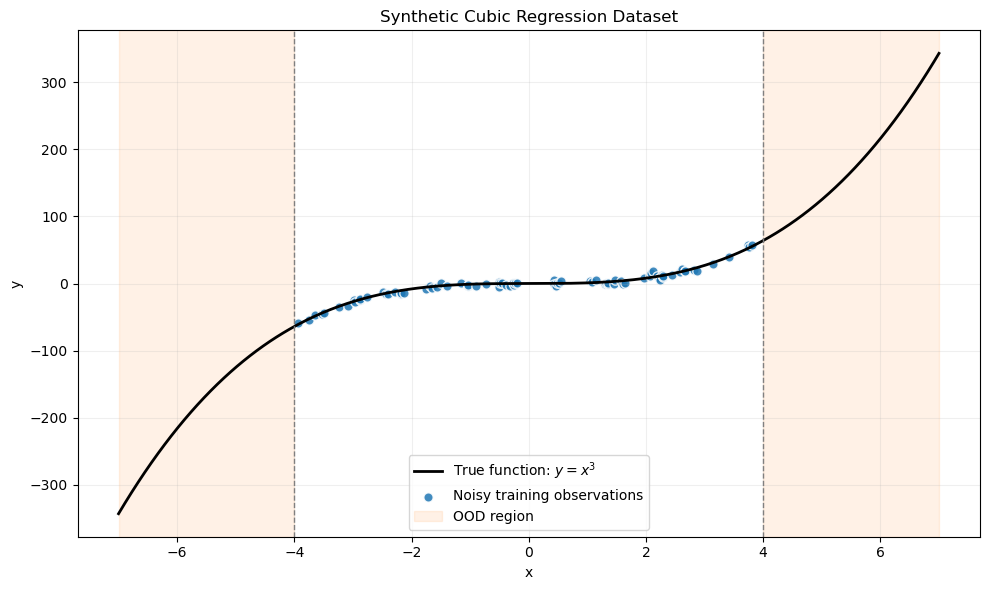

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    x_test,
    y_test_true,
    color="black",
    linewidth=2,
    label=r"True function: $y=x^3$",
)

plt.scatter(
    x_train,
    y_train,
    color="tab:blue",
    edgecolor="white",
    s=45,
    alpha=0.85,
    label="Noisy training observations",
)

plt.axvspan(
    X_TEST_MIN,
    X_TRAIN_MIN,
    color="tab:orange",
    alpha=0.10,
    label="OOD region",
)

plt.axvspan(
    X_TRAIN_MAX,
    X_TEST_MAX,
    color="tab:orange",
    alpha=0.10,
)

plt.axvline(
    X_TRAIN_MIN,
    color="grey",
    linestyle="--",
    linewidth=1,
)

plt.axvline(
    X_TRAIN_MAX,
    color="grey",
    linestyle="--",
    linewidth=1,
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Cubic Regression Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Probabilistic neural network


In [10]:
import torch.nn as nn
import torch.nn.functional as F


class ProbabilisticRegressor(nn.Module):
    """
    Neural network that predicts:

    1. Predictive mean
    2. Aleatoric variance

    Both outputs are in standardised target units.
    """

    def __init__(self, hidden_size=100):
        super().__init__()

        self.feature_network = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )

        self.mean_head = nn.Linear(hidden_size, 1)
        self.raw_variance_head = nn.Linear(hidden_size, 1)

        # Begin with a relatively small positive variance
        nn.init.constant_(self.raw_variance_head.bias, -3.0)

    def forward(self, x):
        features = self.feature_network(x)

        mean = self.mean_head(features)
        raw_variance = self.raw_variance_head(features)

        # Softplus guarantees a positive variance
        variance = F.softplus(raw_variance) + 1e-6

        return mean, variance


test_model = ProbabilisticRegressor(
    hidden_size=HIDDEN_SIZE
).to(device)

with torch.no_grad():
    test_mean, test_variance = test_model(
        x_train_tensor[:5]
    )

print(test_model)
print(f"Mean output shape: {test_mean.shape}")
print(f"Variance output shape: {test_variance.shape}")
print(
    "All predicted variances are positive:",
    bool(torch.all(test_variance > 0).item()),
)

ProbabilisticRegressor(
  (feature_network): Sequential(
    (0): Linear(in_features=1, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
  )
  (mean_head): Linear(in_features=100, out_features=1, bias=True)
  (raw_variance_head): Linear(in_features=100, out_features=1, bias=True)
)
Mean output shape: torch.Size([5, 1])
Variance output shape: torch.Size([5, 1])
All predicted variances are positive: True


## 4. Gaussian negative log-likelihood


In [11]:
def gaussian_nll(target, mean, variance):
    """
    Gaussian negative log-likelihood, excluding the constant
    0.5 * log(2*pi), which does not affect training.
    """
    variance = torch.clamp(variance, min=1e-6)

    loss = 0.5 * (
        torch.log(variance)
        + ((target - mean) ** 2) / variance
    )

    return loss.mean()


# Test the loss before training
with torch.no_grad():
    test_loss = gaussian_nll(
        y_train_tensor[:5],
        test_mean,
        test_variance,
    )

print(f"Test Gaussian NLL: {test_loss.item():.6f}")
print(
    "Loss is finite:",
    bool(torch.isfinite(test_loss).item()),
)

Test Gaussian NLL: 70.718315
Loss is finite: True


## 5. Train independent ensemble members


In [12]:
def train_ensemble_member(member_index):
    """
    Train one independently initialised probabilistic network.
    """
    member_seed = SEED + member_index

    random.seed(member_seed)
    np.random.seed(member_seed)
    torch.manual_seed(member_seed)

    model = ProbabilisticRegressor(
        hidden_size=HIDDEN_SIZE
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    loss_history = []

    model.train()

    for epoch in range(1, EPOCHS + 1):
        optimizer.zero_grad()

        predicted_mean, predicted_variance = model(
            x_train_tensor
        )

        loss = gaussian_nll(
            y_train_tensor,
            predicted_mean,
            predicted_variance,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss for member {member_index + 1} "
                f"at epoch {epoch}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        loss_history.append(loss.item())

        if epoch == 1 or epoch % 300 == 0:
            print(
                f"Member {member_index + 1}/{ENSEMBLE_SIZE} | "
                f"Epoch {epoch:4d}/{EPOCHS} | "
                f"Loss: {loss.item():.6f}"
            )

    return model, loss_history

In [13]:
ensemble_models = []
ensemble_loss_histories = []

for member_index in range(ENSEMBLE_SIZE):
    print("\n" + "=" * 65)
    print(f"Training ensemble member {member_index + 1}")
    print("=" * 65)

    trained_model, member_loss_history = (
        train_ensemble_member(member_index)
    )

    ensemble_models.append(trained_model)
    ensemble_loss_histories.append(
        member_loss_history
    )

print("\nTraining complete")
print(f"Number of trained models: {len(ensemble_models)}")


Training ensemble member 1
Member 1/5 | Epoch    1/1500 | Loss: 8.112485
Member 1/5 | Epoch  300/1500 | Loss: -1.741617
Member 1/5 | Epoch  600/1500 | Loss: -1.800955
Member 1/5 | Epoch  900/1500 | Loss: -1.828939
Member 1/5 | Epoch 1200/1500 | Loss: -1.844678
Member 1/5 | Epoch 1500/1500 | Loss: -1.852259

Training ensemble member 2
Member 2/5 | Epoch    1/1500 | Loss: 8.450606
Member 2/5 | Epoch  300/1500 | Loss: -1.732636
Member 2/5 | Epoch  600/1500 | Loss: -1.755899
Member 2/5 | Epoch  900/1500 | Loss: -1.774443
Member 2/5 | Epoch 1200/1500 | Loss: -1.785183
Member 2/5 | Epoch 1500/1500 | Loss: -1.837884

Training ensemble member 3
Member 3/5 | Epoch    1/1500 | Loss: 10.812547
Member 3/5 | Epoch  300/1500 | Loss: -1.711351
Member 3/5 | Epoch  600/1500 | Loss: -1.705950
Member 3/5 | Epoch  900/1500 | Loss: -1.728243
Member 3/5 | Epoch 1200/1500 | Loss: -1.754775
Member 3/5 | Epoch 1500/1500 | Loss: -1.762204

Training ensemble member 4
Member 4/5 | Epoch    1/1500 | Loss: 6.60485

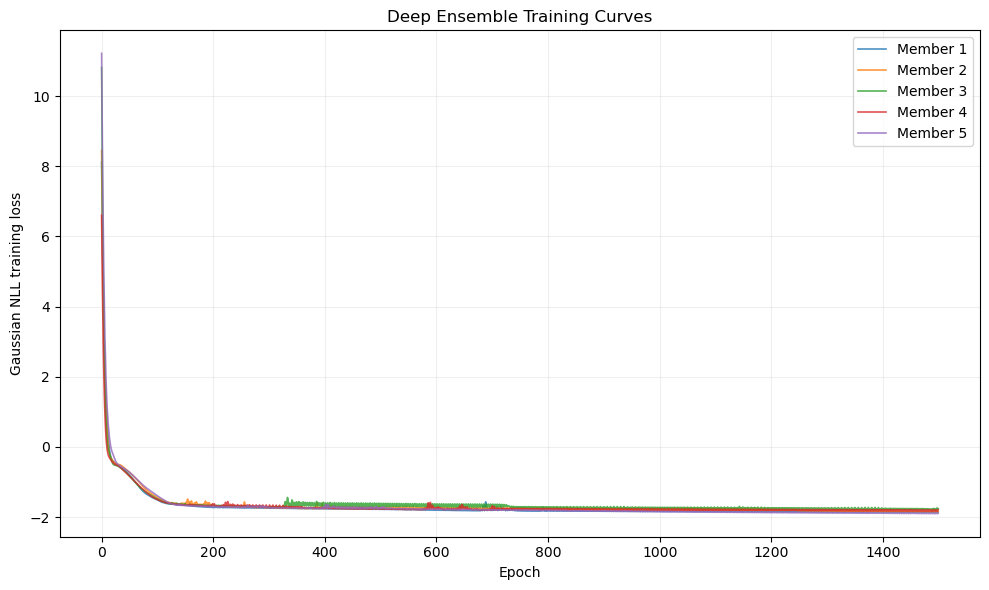

In [14]:
plt.figure(figsize=(10, 6))

for member_index, loss_history in enumerate(
    ensemble_loss_histories
):
    plt.plot(
        loss_history,
        linewidth=1.2,
        alpha=0.8,
        label=f"Member {member_index + 1}",
    )

plt.xlabel("Epoch")
plt.ylabel("Gaussian NLL training loss")
plt.title("Deep Ensemble Training Curves")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Combine ensemble predictions


In [15]:
member_means_standardised = []
member_variances_standardised = []

for model in ensemble_models:
    model.eval()

    with torch.no_grad():
        predicted_mean, predicted_variance = model(
            x_test_tensor
        )

    member_means_standardised.append(
        predicted_mean.squeeze(-1).cpu().numpy()
    )

    member_variances_standardised.append(
        predicted_variance.squeeze(-1).cpu().numpy()
    )

member_means_standardised = np.stack(
    member_means_standardised,
    axis=0,
)

member_variances_standardised = np.stack(
    member_variances_standardised,
    axis=0,
)

# Convert predictions back to original target units
member_means = (
    member_means_standardised * y_std
    + y_mean
)

member_variances = (
    member_variances_standardised * (y_std ** 2)
)

# Deep Ensemble predictive moments
ensemble_mean = member_means.mean(axis=0)

aleatoric_variance = member_variances.mean(axis=0)

epistemic_variance = member_means.var(axis=0)

total_variance = (
    aleatoric_variance
    + epistemic_variance
)

aleatoric_std = np.sqrt(
    np.maximum(aleatoric_variance, 1e-12)
)

epistemic_std = np.sqrt(
    np.maximum(epistemic_variance, 1e-12)
)

total_std = np.sqrt(
    np.maximum(total_variance, 1e-12)
)

lower_95 = ensemble_mean - Z_VALUE * total_std
upper_95 = ensemble_mean + Z_VALUE * total_std

print(f"Member means shape: {member_means.shape}")
print(f"Member variances shape: {member_variances.shape}")
print(f"Ensemble mean shape: {ensemble_mean.shape}")
print(f"Total standard deviation shape: {total_std.shape}")

print(
    "All total variances positive:",
    bool(np.all(total_variance > 0)),
)

Member means shape: (5, 500)
Member variances shape: (5, 500)
Ensemble mean shape: (500,)
Total standard deviation shape: (500,)
All total variances positive: True


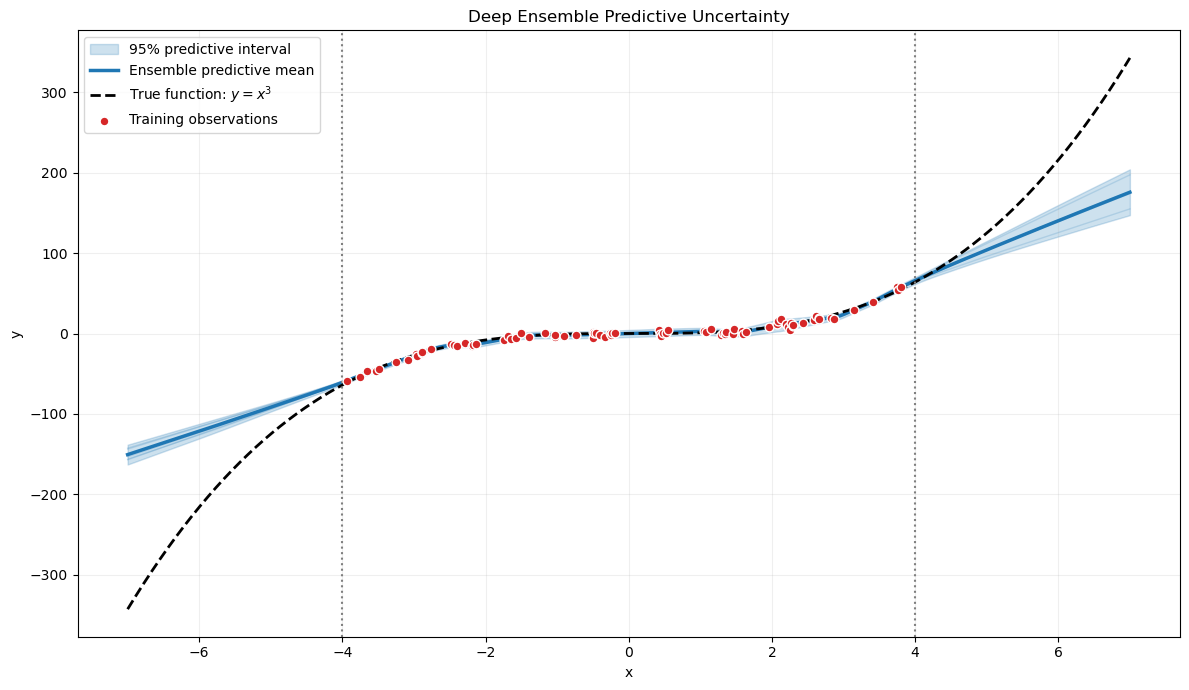

In [16]:
plt.figure(figsize=(12, 7))

# Plot individual member means
for member_index in range(ENSEMBLE_SIZE):
    plt.plot(
        x_test[:, 0],
        member_means[member_index],
        color="tab:blue",
        alpha=0.18,
        linewidth=1,
    )

plt.fill_between(
    x_test[:, 0],
    lower_95,
    upper_95,
    color="tab:blue",
    alpha=0.22,
    label="95% predictive interval",
)

plt.plot(
    x_test[:, 0],
    ensemble_mean,
    color="tab:blue",
    linewidth=2.5,
    label="Ensemble predictive mean",
)

plt.plot(
    x_test[:, 0],
    y_test_true[:, 0],
    color="black",
    linestyle="--",
    linewidth=2,
    label=r"True function: $y=x^3$",
)

plt.scatter(
    x_train[:, 0],
    y_train[:, 0],
    color="tab:red",
    edgecolor="white",
    s=40,
    zorder=5,
    label="Training observations",
)

plt.axvline(
    X_TRAIN_MIN,
    color="grey",
    linestyle=":",
    linewidth=1.5,
)

plt.axvline(
    X_TRAIN_MAX,
    color="grey",
    linestyle=":",
    linewidth=1.5,
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Deep Ensemble Predictive Uncertainty")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Evaluation


In [17]:
evaluation_rng = np.random.default_rng(
    SEED + 10_000
)

y_test_observed = (
    y_test_true[:, 0]
    + evaluation_rng.normal(
        loc=0.0,
        scale=NOISE_STD,
        size=N_TEST,
    )
)

print(f"Evaluation observations: {len(y_test_observed)}")
print(
    f"Observed evaluation noise SD: "
    f"{np.std(y_test_observed - y_test_true[:, 0]):.4f}"
)

Evaluation observations: 500
Observed evaluation noise SD: 2.6969


#### Evaluation metrics

In [18]:
def exact_mixture_nll(
    observed_targets,
    component_means,
    component_variances,
):
    """
    Exact NLL of the equally weighted Gaussian mixture formed by
    the ensemble members.
    """
    observed_targets = np.asarray(observed_targets)[None, :]

    safe_variances = np.maximum(
        component_variances,
        1e-12,
    )

    component_log_probabilities = -0.5 * (
        np.log(2.0 * np.pi * safe_variances)
        + (
            (observed_targets - component_means) ** 2
            / safe_variances
        )
    )

    # Stable log-mean-exp across ensemble members
    maximum_log_probability = np.max(
        component_log_probabilities,
        axis=0,
    )

    mixture_log_probability = (
        maximum_log_probability
        + np.log(
            np.mean(
                np.exp(
                    component_log_probabilities
                    - maximum_log_probability
                ),
                axis=0,
            )
        )
    )

    return float(-np.mean(mixture_log_probability))


def calculate_metrics(mask, region_name):
    region_true_mean = y_test_true[:, 0][mask]
    region_observed = y_test_observed[mask]
    region_prediction = ensemble_mean[mask]

    region_lower = lower_95[mask]
    region_upper = upper_95[mask]

    rmse = np.sqrt(
        np.mean(
            (region_prediction - region_true_mean) ** 2
        )
    )

    nll = exact_mixture_nll(
        region_observed,
        member_means[:, mask],
        member_variances[:, mask],
    )

    coverage = np.mean(
        (region_observed >= region_lower)
        & (region_observed <= region_upper)
    )

    mean_interval_width = np.mean(
        region_upper - region_lower
    )

    mean_aleatoric_std = np.mean(
        aleatoric_std[mask]
    )

    mean_epistemic_std = np.mean(
        epistemic_std[mask]
    )

    mean_total_std = np.mean(
        total_std[mask]
    )

    return {
        "Region": region_name,
        "Points": int(mask.sum()),
        "RMSE": rmse,
        "Mixture NLL": nll,
        "95% Coverage": coverage,
        "Mean Interval Width": mean_interval_width,
        "Mean Aleatoric SD": mean_aleatoric_std,
        "Mean Epistemic SD": mean_epistemic_std,
        "Mean Total SD": mean_total_std,
    }

#### Calculate and display the results

In [19]:
all_mask = np.ones(
    N_TEST,
    dtype=bool,
)

results = [
    calculate_metrics(
        id_mask,
        "In-distribution",
    ),
    calculate_metrics(
        ood_mask,
        "Out-of-distribution",
    ),
    calculate_metrics(
        all_mask,
        "Full evaluation range",
    ),
]

results_df = pd.DataFrame(results)

numeric_columns = results_df.select_dtypes(
    include=[np.number]
).columns

results_df[numeric_columns] = (
    results_df[numeric_columns].round(4)
)

results_df

,Region,Points,RMSE,Mixture NLL,95% Coverage,Mean Interval Width,Mean Aleatoric SD,Mean Epistemic SD,Mean Total SD
0,In-distribution,286,1.5269,3.0311,0.7657,8.105300,2.0017,0.4260,2.0677
1,Out-of-distribution,214,84.4110,1086.2271,0.1028,22.961901,2.1714,5.3814,5.8576
2,Full evaluation range,500,55.2352,466.6390,0.4820,14.464000,2.0743,2.5469,3.6898


#### Comparing in-distribution and OOD uncertainty

In [20]:
mean_id_epistemic = float(
    epistemic_std[id_mask].mean()
)

mean_ood_epistemic = float(
    epistemic_std[ood_mask].mean()
)

mean_id_total = float(
    total_std[id_mask].mean()
)

mean_ood_total = float(
    total_std[ood_mask].mean()
)

epistemic_ood_ratio = (
    mean_ood_epistemic
    / max(mean_id_epistemic, 1e-12)
)

total_ood_ratio = (
    mean_ood_total
    / max(mean_id_total, 1e-12)
)

print(
    f"Mean ID epistemic SD: "
    f"{mean_id_epistemic:.4f}"
)
print(
    f"Mean OOD epistemic SD: "
    f"{mean_ood_epistemic:.4f}"
)
print(
    f"OOD/ID epistemic uncertainty ratio: "
    f"{epistemic_ood_ratio:.4f}"
)

print()

print(
    f"Mean ID total SD: "
    f"{mean_id_total:.4f}"
)
print(
    f"Mean OOD total SD: "
    f"{mean_ood_total:.4f}"
)
print(
    f"OOD/ID total uncertainty ratio: "
    f"{total_ood_ratio:.4f}"
)

Mean ID epistemic SD: 0.4260
Mean OOD epistemic SD: 5.3814
OOD/ID epistemic uncertainty ratio: 12.6321

Mean ID total SD: 2.0677
Mean OOD total SD: 5.8576
OOD/ID total uncertainty ratio: 2.8330


#### Plot the uncertainty decomposition

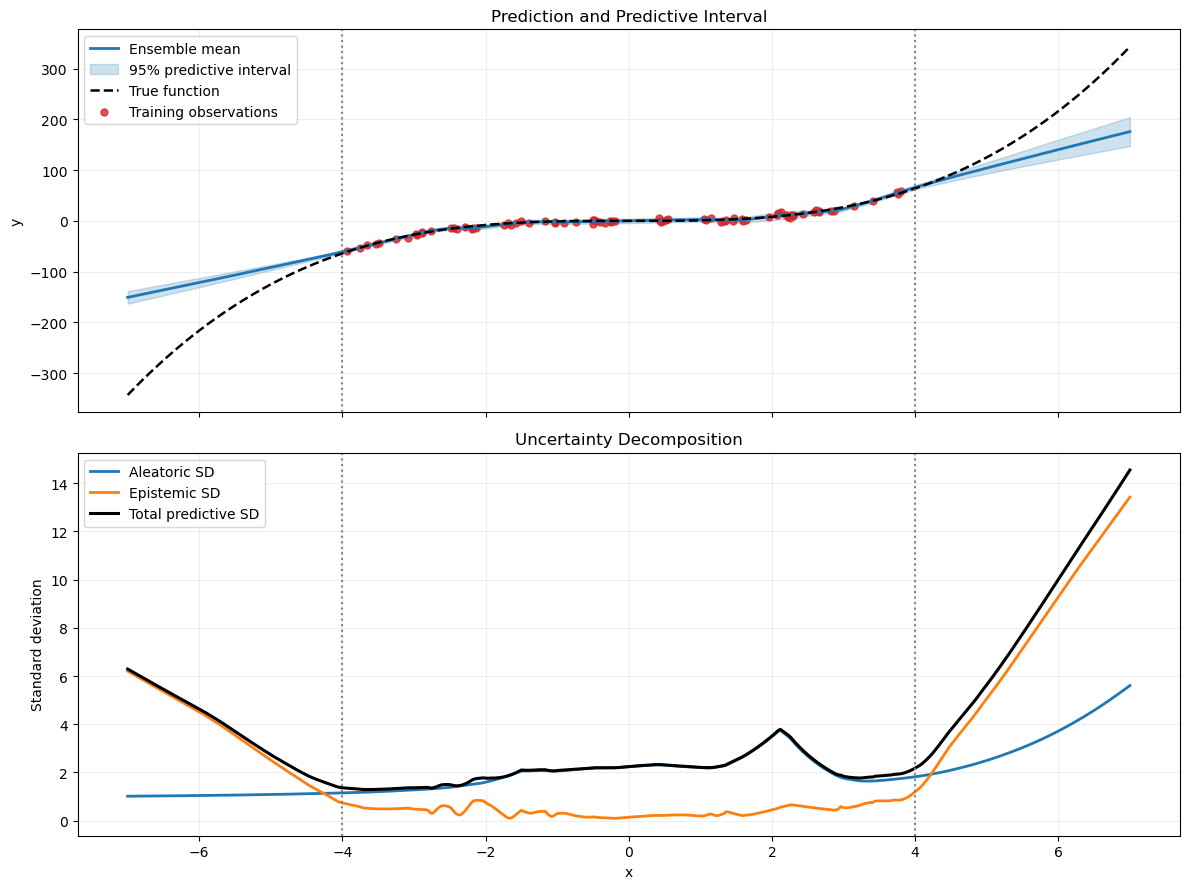

In [21]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
)

axes[0].plot(
    x_test[:, 0],
    ensemble_mean,
    color="tab:blue",
    linewidth=2,
    label="Ensemble mean",
)

axes[0].fill_between(
    x_test[:, 0],
    lower_95,
    upper_95,
    color="tab:blue",
    alpha=0.22,
    label="95% predictive interval",
)

axes[0].plot(
    x_test[:, 0],
    y_test_true[:, 0],
    color="black",
    linestyle="--",
    linewidth=1.8,
    label="True function",
)

axes[0].scatter(
    x_train[:, 0],
    y_train[:, 0],
    color="tab:red",
    s=25,
    alpha=0.8,
    label="Training observations",
)

axes[0].set_ylabel("y")
axes[0].set_title("Prediction and Predictive Interval")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(
    x_test[:, 0],
    aleatoric_std,
    linewidth=2,
    label="Aleatoric SD",
)

axes[1].plot(
    x_test[:, 0],
    epistemic_std,
    linewidth=2,
    label="Epistemic SD",
)

axes[1].plot(
    x_test[:, 0],
    total_std,
    color="black",
    linewidth=2.2,
    label="Total predictive SD",
)

for axis in axes:
    axis.axvline(
        X_TRAIN_MIN,
        color="grey",
        linestyle=":",
    )
    axis.axvline(
        X_TRAIN_MAX,
        color="grey",
        linestyle=":",
    )

axes[1].set_xlabel("x")
axes[1].set_ylabel("Standard deviation")
axes[1].set_title("Uncertainty Decomposition")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

#### Calibration curve

In [22]:
from scipy.stats import norm


nominal_levels = np.array([
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99,
])

empirical_coverages = []

for nominal_level in nominal_levels:
    z_score = norm.ppf(
        (1.0 + nominal_level) / 2.0
    )

    interval_lower = (
        ensemble_mean - z_score * total_std
    )

    interval_upper = (
        ensemble_mean + z_score * total_std
    )

    empirical_coverage = np.mean(
        (
            y_test_observed[id_mask]
            >= interval_lower[id_mask]
        )
        & (
            y_test_observed[id_mask]
            <= interval_upper[id_mask]
        )
    )

    empirical_coverages.append(
        empirical_coverage
    )

empirical_coverages = np.array(
    empirical_coverages
)

mean_calibration_error = np.mean(
    np.abs(
        empirical_coverages
        - nominal_levels
    )
)

calibration_df = pd.DataFrame({
    "Nominal coverage": nominal_levels,
    "Empirical ID coverage": empirical_coverages,
    "Absolute gap": np.abs(
        empirical_coverages - nominal_levels
    ),
}).round(4)

print(
    f"Mean absolute calibration error: "
    f"{mean_calibration_error:.4f}"
)

calibration_df

Mean absolute calibration error: 0.1832


,Nominal coverage,Empirical ID coverage,Absolute gap
0,0.50,0.3182,0.1818
1,0.60,0.4126,0.1874
2,0.70,0.5000,0.2000
3,0.80,0.5944,0.2056
4,0.90,0.6993,0.2007
5,0.95,0.7657,0.1843
6,0.99,0.8671,0.1229


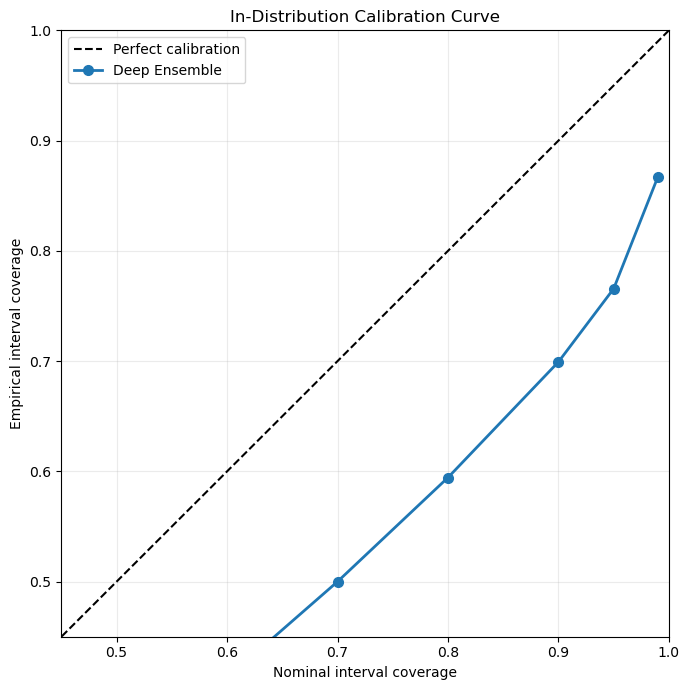

In [23]:
plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration",
)

plt.plot(
    nominal_levels,
    empirical_coverages,
    marker="o",
    markersize=7,
    linewidth=2,
    color="tab:blue",
    label="Deep Ensemble",
)

plt.xlabel("Nominal interval coverage")
plt.ylabel("Empirical interval coverage")
plt.title("In-Distribution Calibration Curve")
plt.xlim(0.45, 1.0)
plt.ylim(0.45, 1.0)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusions

In [24]:
id_result = results_df.loc[
    results_df["Region"] == "In-distribution"
].iloc[0]

ood_result = results_df.loc[
    results_df["Region"] == "Out-of-distribution"
].iloc[0]

print("DEEP ENSEMBLE EXPERIMENT SUMMARY")
print("=" * 50)

print(
    f"ID RMSE: {id_result['RMSE']:.4f}"
)
print(
    f"ID mixture NLL: "
    f"{id_result['Mixture NLL']:.4f}"
)
print(
    f"ID 95% coverage: "
    f"{id_result['95% Coverage']:.4f}"
)
print(
    f"ID mean interval width: "
    f"{id_result['Mean Interval Width']:.4f}"
)
print(
    f"Mean calibration error: "
    f"{mean_calibration_error:.4f}"
)
print(
    f"OOD/ID epistemic uncertainty ratio: "
    f"{epistemic_ood_ratio:.4f}"
)
print(
    f"OOD/ID total uncertainty ratio: "
    f"{total_ood_ratio:.4f}"
)

print("\nInterpretation")

if epistemic_ood_ratio > 1:
    print(
        "- Epistemic uncertainty is higher on average "
        "outside the training region."
    )
else:
    print(
        "- Epistemic uncertainty did not increase on "
        "average outside the training region."
    )

coverage_gap = abs(
    float(id_result["95% Coverage"]) - 0.95
)

print(
    f"- The ID 95% coverage differs from the nominal "
    f"level by {coverage_gap:.4f}."
)

print(
    "- These results provide the Deep Ensemble baseline "
    "for the later ACCRUE comparison."
)

DEEP ENSEMBLE EXPERIMENT SUMMARY
ID RMSE: 1.5269
ID mixture NLL: 3.0311
ID 95% coverage: 0.7657
ID mean interval width: 8.1053
Mean calibration error: 0.1832
OOD/ID epistemic uncertainty ratio: 12.6321
OOD/ID total uncertainty ratio: 2.8330

Interpretation
- Epistemic uncertainty is higher on average outside the training region.
- The ID 95% coverage differs from the nominal level by 0.1843.
- These results provide the Deep Ensemble baseline for the later ACCRUE comparison.


### Main findings

This experiment trained five independently initialised probabilistic neural
networks on the same noisy cubic regression dataset. Each network predicted a
mean and an aleatoric variance.

The ensemble predictive mean was obtained by averaging the member means.
Predictive uncertainty was separated into:

- **Aleatoric uncertainty:** uncertainty associated with observation noise.
- **Epistemic uncertainty:** uncertainty produced by disagreement between the
  independently trained networks.
- **Total predictive uncertainty:** the sum of aleatoric and epistemic
  variances.

The method was evaluated using RMSE, Gaussian-mixture negative
log-likelihood, prediction-interval coverage, interval width, calibration and
out-of-distribution uncertainty.

This notebook is a simplified implementation of the principal Deep Ensemble
regression method. The same dataset, evaluation points and metrics will be
reused in the ACCRUE notebook so that the final comparison is controlled and
fair.